<a href="https://colab.research.google.com/github/Bilra-Hkr/DerielChaerahman_2411533007_ML2526/blob/main/Praktikum2/BernoulliNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Load dataset
dataset_dict = {
    'Outlook': ['sunny', 'sunny', 'overcast', 'rainy', 'rainy', 'rainy', 'overcast', 'sunny', 'sunny', 'rainy', 'sunny', 'overcast', 'overcast', 'rainy', 'sunny', 'overcast', 'rainy', 'sunny', 'sunny', 'rainy', 'overcast', 'rainy', 'sunny', 'overcast', 'sunny', 'overcast', 'rainy', 'overcast'],
    'Temperature': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0, 72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0, 88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
    'Humidity': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0, 90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0, 65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
    'Wind': [False, True, False, False, False, True, True, False, False, False, True, True, False, True, True, False, False, True, False, True, True, False, True, False, False, True, False, False],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes']
}
df = pd.DataFrame(dataset_dict)

df.head()

,Outlook,Temperature,Humidity,Wind,Play
0,sunny,85.0,85.0,False,No
1,sunny,80.0,90.0,True,No
2,overcast,83.0,78.0,False,Yes
3,rainy,70.0,96.0,False,Yes
4,rainy,68.0,80.0,False,Yes


In [2]:
df.tail()

,Outlook,Temperature,Humidity,Wind,Play
23,overcast,77.0,70.0,False,Yes
24,sunny,79.0,60.0,False,Yes
25,overcast,80.0,95.0,True,Yes
26,rainy,66.0,70.0,False,No
27,overcast,84.0,78.0,False,Yes


<Axes: >

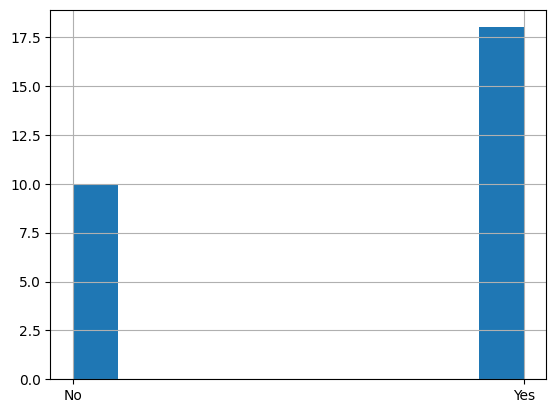

In [5]:
# Tampilkan hisrogram unutk class/target data dimiliki
df["Play"].hist()

In [6]:
# Data Preprocessing : konversi input 0 dan 1
df = pd.get_dummies(df, columns=['Outlook'], prefix='', prefix_sep='', dtype=int)

# CONVERT 'Windy' (bool) and 'Play' (binary) COLUMNS TO BINARY INDICATORS
df['Wind'] = df['Wind'].astype(int)
df['Play'] = (df['Play'] == 'Yes').astype(int)

df.head()

,Temperature,Humidity,Wind,Play,overcast,rainy,sunny
0,85.0,85.0,0,0,0,0,1
1,80.0,90.0,1,0,0,0,1
2,83.0,78.0,0,1,1,0,0
3,70.0,96.0,0,1,0,1,0
4,68.0,80.0,0,1,0,1,0


In [7]:
# One-hot encode the categorized columns and drop them after
# Define categories for 'Temperature' and 'Humidity' for dataframe
df['Temperature'] = pd.cut(df['Temperature'], bins=[0, 80, 100], labels=['Warm', 'Hot'])
df['Humidity'] = pd.cut(df['Humidity'], bins=[0, 75, 100], labels=['Dry', 'Humid'])

# One-hot encode the categorized columns
one_hot_columns = pd.get_dummies(df[['Temperature', 'Humidity']], drop_first=True, dtype=int)

# Drop the categorized columns from df
df = df.drop(['Temperature', 'Humidity'], axis=1)

# Concatenate the one-hot encoded columns with the original DataFrames
df = pd.concat([one_hot_columns, df], axis=1)

df.head()

,Temperature_Hot,Humidity_Humid,Wind,Play,overcast,rainy,sunny
0,1,1,0,0,0,0,1
1,0,1,1,0,0,0,1
2,1,1,0,1,1,0,0
3,0,1,0,1,0,1,0
4,0,1,0,1,0,1,0


In [8]:
# bagi data uji dan latih
X, y = df.drop(columns='Play'), df['Play']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=False)

In [10]:
# Latih model
nb_clf = BernoulliNB()
nb_clf.fit(X_train, y_train)

BernoulliNB()

In [12]:
# Buat prediksi
y_pred = nb_clf.predict(X_test)

# Cek Akurasi
print(f"Akurasi : {accuracy_score(y_test, y_pred)}")

Akurasi : 0.5555555555555556


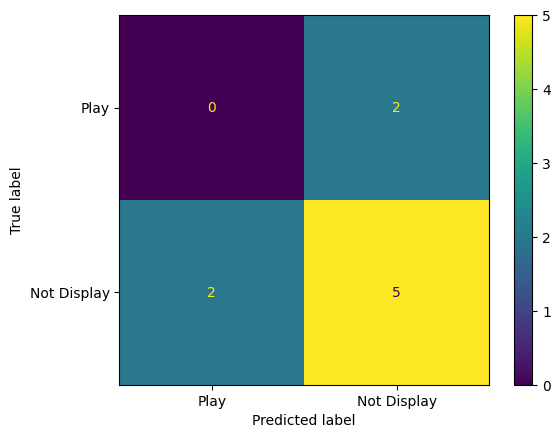

In [14]:
# Analisis kinerja model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["Play", "Not Display"]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();